# Wstęp teoretyczny

Render AI odnosi się do technik, w których sztuczna inteligencja, najczęściej w postaci Głębokiego Uczenia (Deep Learning), jest wykorzystywana do przyspieszenia, ulepszenia lub zastąpienia konwencjonalnych, kosztownych obliczeniowo procesów renderingu.


## Podstawowe definicje:
| Pojęcie | Definicja | Przykład zastosowania |
|--------|-----------|----------------------|
| Renderowanie (rendering) | Proces generowania obrazu 2D na podstawie opisu sceny 2D lub 3D (geometria, materiały, światło, kamera). | Wizualizacja budynku, klatka filmu animowanego |
| Grafika komputerowa | Dziedzina informatyki zajmująca się tworzeniem i przetwarzaniem obrazów oraz animacji komputerowych. | Gry komputerowe, animacje, wizualizacje |
| Rasteryzacja | Technika renderowania zamieniająca obiekty geometryczne na piksele obrazu. | Renderowanie grafiki w czasie rzeczywistym |
| Ray tracing | Metoda renderowania symulująca fizyczne rozchodzenie się promieni światła w scenie. | Realistyczne odbicia i cienie |
| Sztuczna inteligencja (AI) | Metody umożliwiające komputerom wykonywanie zadań wymagających inteligencji. | Analiza obrazów, systemy rekomendacji |
| Uczenie maszynowe | Poddziedzina AI, w której modele uczą się zależności na podstawie danych. | Klasyfikacja obrazów |
| Uczenie głębokie (deep learning) | Forma uczenia maszynowego oparta na wielowarstwowych sieciach neuronowych. | Generowanie i analiza obrazów |
| Konwolucyjne sieci neuronowe (CNN) | Sieci neuronowe przeznaczone do przetwarzania danych obrazowych. | Wykrywanie obiektów |
| Modele generatywne | Modele zdolne do tworzenia nowych danych na podstawie zbioru uczącego. | Generowanie obrazów i tekstur |
| Super-rozdzielczość | Technika zwiększania rozdzielczości obrazu przy użyciu AI. | Skalowanie obrazu |
| Redukcja szumu (denoising) | Usuwanie zakłóceń i artefaktów z obrazu. | Przyspieszanie ray tracingu |
| Render AI | Zastosowanie AI do wspomagania renderowania obrazu. | AI denoiser w Blenderze |


Źródło: https://vibe3d.ai/blog/render-ai

# Zadanie 1 - Prosty Denoising
Poniższy przykład należy przeprowadzić dla datasetu CIFAT-10, rozmiary obrazków 128x128.

**Krok 1**: Przygotowanie Danych (Symulacja Szumu)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Brak pliku 'scena.jpg'. Generuję syntetyczny obraz testowy.
Czysty obraz: torch.Size([1, 1, 64, 64]), Zaszumiony: torch.Size([1, 1, 64, 64])


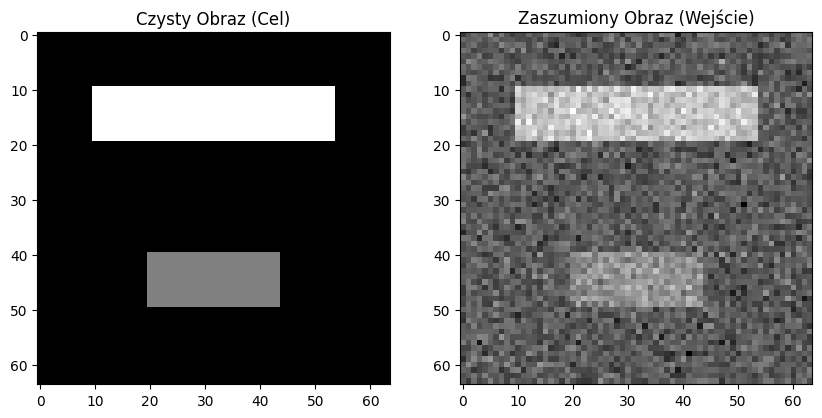

In [ ]:
# Użyjemy prostego obrazu
# Zastąp 'scena.jpg' ścieżką do dowolnego pliku obrazu, np. z internetu
# Dla uproszczenia, zakładamy, że mamy mały obraz (np. 256x256)
try:
    img = Image.open('scena.jpg').convert('L') # Konwersja na skalę szarości dla prostoty
    img = transforms.ToTensor()(img).unsqueeze(0) # [1, 1, H, W]
except FileNotFoundError:
    print("Brak pliku 'scena.jpg'. Generuję syntetyczny obraz testowy.")
    # Generowanie syntetycznego "czystego" obrazu
    img = torch.zeros(1, 1, 64, 64)
    img[:, :, 10:20, 10:54] = 1.0
    img[:, :, 40:50, 20:44] = 0.5

CLEAN_IMAGE = img.float()

# 1. Dodanie szumu (symulacja "szumnego" renderu)
# Szum Gaussowski, np. o odchyleniu standardowym 0.2
noise = torch.randn_like(CLEAN_IMAGE) * 0.2
NOISY_IMAGE = CLEAN_IMAGE + noise

print(f"Czysty obraz: {CLEAN_IMAGE.shape}, Zaszumiony: {NOISY_IMAGE.shape}")

# Wizualizacja danych
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Czysty Obraz (Cel)")
plt.imshow(CLEAN_IMAGE.squeeze().numpy(), cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Zaszumiony Obraz (Wejście)")
plt.imshow(NOISY_IMAGE.squeeze().numpy(), cmap='gray')
plt.show()

**Krok 2**: Definicja Minimalnej Sieci CNN (Autoenkoder)

In [ ]:
class SimpleDenoiser(nn.Module):
    def __init__(self):
        super(SimpleDenoiser, self).__init__()
        # 1x1 conv - wejście na 32 kanały
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # 32x32 conv - dekodowanie/wyjście z powrotem na 1 kanał (obraz)
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid() # Sigmoid, aby wartości były w zakresie [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = SimpleDenoiser()
print("Model Denoisera zdefiniowany.")

Model Denoisera zdefiniowany.


**Krok 3**: Trening Sieci

In [ ]:
# Ustawienia treningu
criterion = nn.MSELoss() # Funkcja straty: Średni Błąd Kwadratowy (Mean Squared Error)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 500 # Ilość epok (dla tak prostego zadania, 500 wystarczy)
loss_history = []

print("Rozpoczęcie treningu...")
for epoch in range(epochs):
    optimizer.zero_grad() # Zerowanie gradientów

    # Wykonanie przejścia w przód (Forward Pass)
    output = model(NOISY_IMAGE)

    # Obliczenie straty
    loss = criterion(output, CLEAN_IMAGE)
    loss_history.append(loss.item())

    # Wykonanie przejścia wstecz (Backward Pass) i optymalizacja
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata (Loss): {loss.item():.6f}')

print("Trening zakończony.")

Rozpoczęcie treningu...
Epoka [100/500], Strata (Loss): 0.006126
Epoka [200/500], Strata (Loss): 0.001285
Epoka [300/500], Strata (Loss): 0.000683
Epoka [400/500], Strata (Loss): 0.000389
Epoka [500/500], Strata (Loss): 0.000204
Trening zakończony.


**Krok 4**: Wizualizacja Wyników

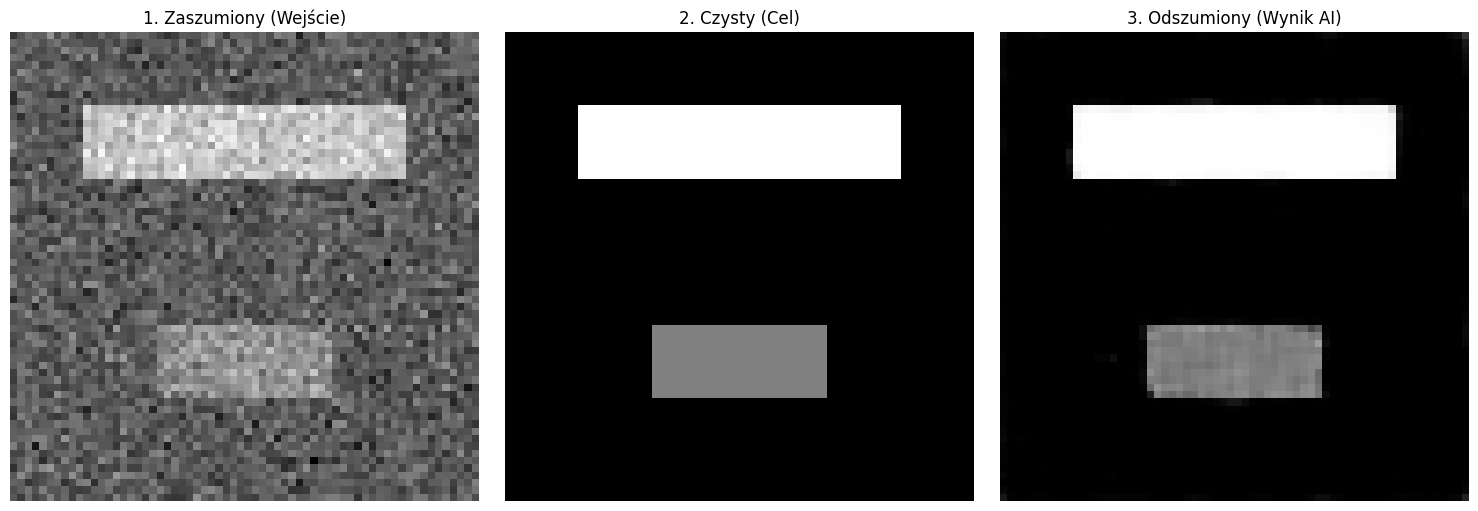

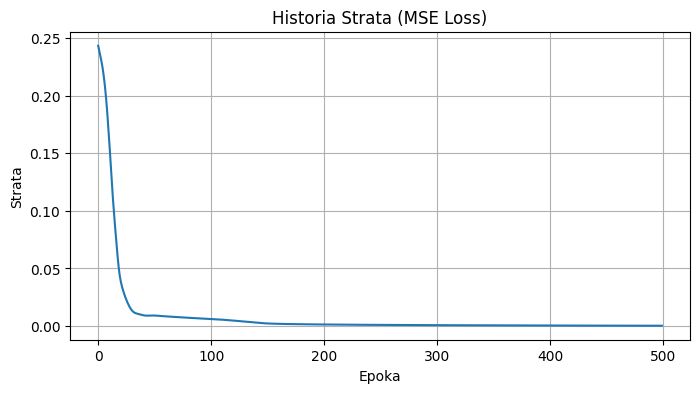

In [ ]:
# Ocena modelu (wygenerowanie odszumionego obrazu)
model.eval()
with torch.no_grad():
    DENOISED_IMAGE = model(NOISY_IMAGE).squeeze().numpy()

# Wizualizacja końcowych wyników
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Zaszumiony Obraz (Wejście)
axes[0].set_title("1. Zaszumiony (Wejście)")
axes[0].imshow(NOISY_IMAGE.squeeze().numpy(), cmap='gray')
axes[0].axis('off')

# 2. Czysty Obraz (Cel)
axes[1].set_title("2. Czysty (Cel)")
axes[1].imshow(CLEAN_IMAGE.squeeze().numpy(), cmap='gray')
axes[1].axis('off')

# 3. Odszumiony Obraz (Wynik AI)
axes[2].set_title("3. Odszumiony (Wynik AI)")
axes[2].imshow(DENOISED_IMAGE, cmap='gray')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Wykres historii straty
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Trening (MSE Loss)')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Zadanie 2 - Chałupniczy Upscaling

Dataset: CIFAR‑10 (obrazki 128x128)

1. Przygotować obrazki o rozmiarach 128x128 w 3 rozmiarach: 128x128, 96x96, 64x64
2. Przygotować kaskadę enkoderów, które mają uczyć się poszerzania obrazka z 64x64 do 96x96 i do 128x128.
3. Wytrenownay model do od-szumiania wykorzystać do poprawy jakości obrazu wyjściowego z kaskady enkoderów.